In [ ]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE


from method.preprocessing import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Datasets
DATASET_PATH="../../Ressources/Dataset/corpus.tache1.learn.utf8"
TEST_PATH="../../Ressources/Projet Test Set-20260316/corpus.tache1.test.utf8"
# Répertoires -> Résultats + Modèles entrainées
RESULT_ROOT="../../Results"
MODELS_ROOT="../../Models/Dialogs"

RUN_CLASSICAL = True
RUN_W2V = True
RUN_RNN = True
RUN_TRANSFORMER = True


In [337]:
try:
    train_labels,train_texts=load_pres(DATASET_PATH,for_train=True)
    test_texts=load_pres(TEST_PATH,for_train=False)
    print("="*50)
    print(" "*10,"Dataset Chargé")
    print("="*50)
    print(f"Train : {len(train_texts)} phrases")
    print(f"Test  : {len(test_texts)} phrases")
    print("Répartition des classes :", Counter(train_labels))
    print("0 = Chirac, 1 = Mitterrand")
except Exception as e:
    raise AssertionError("Echec de chargement dataset train/test") from e



           Dataset Chargé
Train : 57413 phrases
Test  : 27162 phrases
Répartition des classes : Counter({np.int64(0): 49890, np.int64(1): 7523})
0 = Chirac, 1 = Mitterrand


## Baseline : TF-IDF + SVM avec grande classe imbalance

In [ ]:
X_train_baseline, X_val_baseline, y_train_baseline, y_val_baseline = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42, stratify=train_labels, shuffle=True
)

models = {
    #"logreg": LogisticRegression(max_iter=3000),
    "svm": LinearSVC(C=1.0, class_weight="balanced")
}


best_model_name = None
best_score = 0
best_pipeline = None

for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(# stop_words=stop_words, 
                                  preprocessor = preprocess_pred,
                                  # analyzer="char",
                                  # ngram_range=(3,5), 
                                  lowercase=True,
                                  ngram_range=(1,3),
                                  min_df=2,
                                  max_df=0.8,
                                  sublinear_tf=True
                                    )
                                  ),
        #("tfidf", TfidfVectorizer(ngram_range=(3,5), max_features=30000, analyzer="char", sublinear_tf=True)),
        ("clf", clf)
    ])

    pipe.fit(X_train_baseline, y_train_baseline)
    train_preds = pipe.predict(X_train_baseline)
    val_preds = pipe.predict(X_val_baseline)

    train_f1 = f1_score(y_train, train_preds, average="macro")
    val_f1 = f1_score(y_val_baseline, val_preds, average="macro")

    print(f"\n{name}")
    print(f"Train F1: {train_f1:.4f}")
    print(f"Val F1:   {val_f1:.4f}")
    print(classification_report(y_val_baseline, val_preds, digits=4))

    if val_f1 > best_score:
        best_score = val_f1
        best_model_name = name
        best_pipeline = pipe

print(f"\nBest model: {best_model_name} (F1: {best_score:.4f})")


svm
Train F1: 0.9934
Val F1:   0.7778
              precision    recall  f1-score   support

           0     0.9412    0.9431    0.9421      9978
           1     0.6175    0.6093    0.6134      1505

    accuracy                         0.8993     11483
   macro avg     0.7793    0.7762    0.7778     11483
weighted avg     0.8988    0.8993    0.8990     11483


Best model: svm (F1: 0.7778)


### Avant l'augmentation des données, on garde 10% du dataset de base pour effectuer des tests plus tard 

In [290]:
X_train_split, X_test, y_train_split, y_test = train_test_split(
    train_texts, train_labels, test_size=0.1, random_state=42, stratify=train_labels, shuffle=True
)

In [186]:
len(X_train_split)


51671

## Augmentation des données 
### Objectif : équilibrer les classes --> recherche d'au moins 40 000 phrases dites par Mitterrand

In [252]:
import spacy 
nlp = spacy.load("fr_core_news_lg")

In [321]:
def preprocess_mitterrand(phrases, shuffle=True):
    final_data = []
    
    for doc in nlp.pipe(phrases, batch_size=128, disable=["parser", "lemmatizer"]): # par batch pour aller plus vite 
        tokens = [token.text for token in doc]
        
        # Remplacement des noms de personnes par la balise <nom> et des dates par <date> pour correspondre au preprocessing déjà fait sur les données de test et train
        for ent in reversed(doc.ents):
            if ent.label_ == "PER":
                label = "<nom>"
            elif ent.label_ in ["DATE", "TIME"]:
                label = "<date>"
            else:
                continue
            
            tokens[ent.start : ent.end] = [label]
            
        # Reconstruction de la phrase
        clean_text = "".join([t + (" " if doc[i].whitespace_ else "") for i, t in enumerate(tokens)])
        final_data.append(clean_text.strip())

    if shuffle:
        random.shuffle(final_data)
        
    return final_data

In [322]:
# mitt_sentences = load_mitterrand()
with open("mitterrand.txt", "r", encoding="utf-8") as f:
    text = f.read()


text = re.sub(r"(?m)^-\s*", "", text)
text = text.replace("\ufeff"," ")
text = text.replace("\n"," ")


mitt_sentences = re.findall(r'[^.!?]+[.!?]+', text)

mitt_sentences = [s.strip() for s in mitt_sentences if s.strip()]
mitt_sentences = preprocess_mitterrand(mitt_sentences)

mitt_labels = np.ones(len(mitt_sentences), dtype=int)


In [324]:
print(f"{len(mitt_sentences)} phrases extraites")
print(mitt_sentences[:100])
print(X_train_split[:100])

22479 phrases extraites
["Et que ces frères, s'ils étaient ennemis, étaient d'abord des frères et c'est ce qu'il faut rappeler.", "Cela se discute pour l'instant.", "Ce soir, c'est différent, nous sommes en automne et un automne un peu froid.", 'En mai, nouveau référendum au Danemark.', 'Monsieur le Maire, mesdames et messieurs les conseillers municipaux, je vous remercie de cet accueil dans votre Hôtel de Ville.', "J'avais connu Mandela dès sa sortie de prison - il y est resté quelques 27 ans - et il est souvent venu me voir.", "Donc, il faut s'adresser à ceux qui vivent cette vie-là, qui entendent et qui connaissent les autres.", 'Je crois qu\'on peut dire de toutes ces femmes, tous ces hommes que vous êtes ou ceux qui vous ont précédés, ce que disait d\'eux <nom>, je le cite : "c\'est la force de leur passion qui a créé la force de la règle".', "Encore faut-il que les défenseurs de l'Europe se fassent entendre !", 'Mais, <nom> et <nom>, nous avons, nous en avons changé de siècle en 

In [338]:
final_texts = np.concatenate([X_train_split,mitt_sentences])
final_labels = np.concatenate([y_train_split, mitt_labels])

print(f"Train : {len(final_texts)} phrases")
print("Répartition des classes :", Counter(final_labels))
print("0 = Chirac, 1 = Mitterrand")

Train : 74150 phrases
Répartition des classes : Counter({np.int64(0): 44900, np.int64(1): 29250})
0 = Chirac, 1 = Mitterrand


## Courte EDA 

74150 texts | 74150 labels


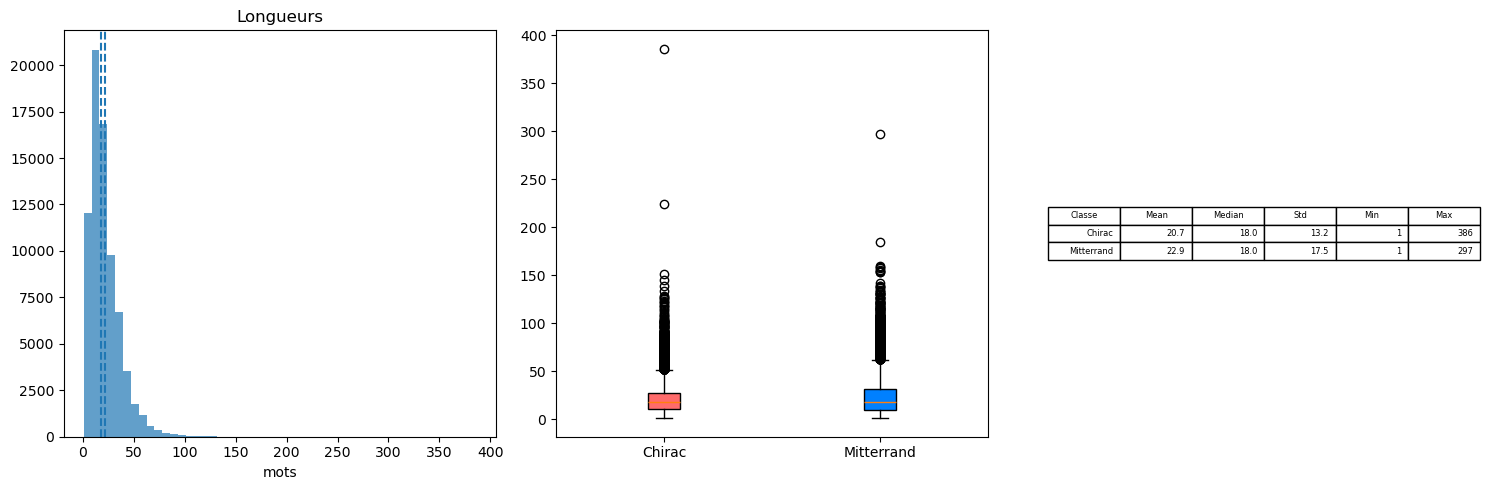

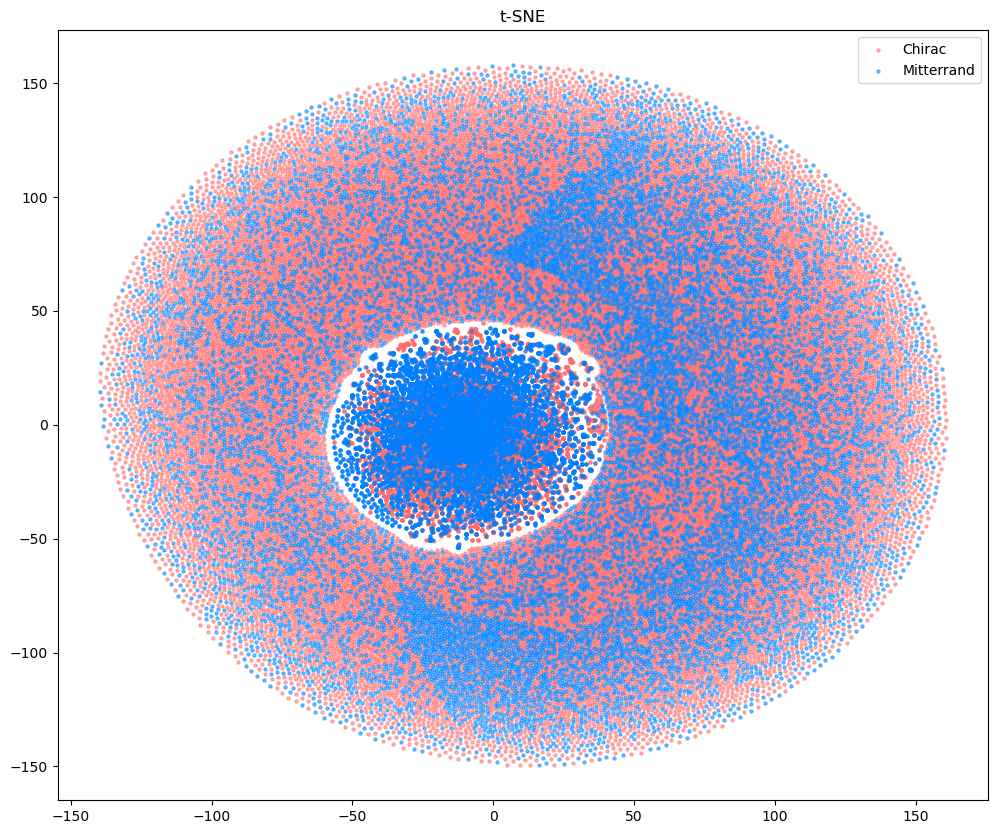

In [339]:
texts, labels = final_texts, np.array(final_labels)
colors = ['#ff6b6b', '#0080FF']
names = ['Chirac', 'Mitterrand']

print(len(texts), "texts |", len(labels), "labels")

# longueurs
lengths = np.array([len(t.split()) for t in texts])
by_class = [lengths[labels == i] for i in [0, 1]]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Histogramme
ax[0].hist(lengths, bins=50, alpha=0.7)
ax[0].axvline(lengths.mean(), ls='--')
ax[0].axvline(np.median(lengths), ls='--')
ax[0].set(title="Longueurs", xlabel="mots")

# Boxplot
bp = ax[1].boxplot(by_class, labels=names, patch_artist=True)
for b, c in zip(bp['boxes'], colors):
    b.set_facecolor(c)

# Stats table
stats = pd.DataFrame({
    'Classe': names,
    'Mean': [x.mean() for x in by_class],
    'Median': [np.median(x) for x in by_class],
    'Std': [x.std() for x in by_class],
    'Min': [x.min() for x in by_class],
    'Max': [x.max() for x in by_class],
})
ax[2].axis('off')
ax[2].table(cellText=stats.round(1).values, colLabels=stats.columns, loc='center')

plt.tight_layout()
plt.savefig('stats.png')
plt.show()

vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vec.fit_transform(texts)

if len(texts) > 30:
    tsne = TSNE(n_components=2, perplexity=min(30, len(texts)-1), random_state=42)
    X2d = tsne.fit_transform(X.toarray())

    plt.figure(figsize=(12, 10))
    for i, c, n in zip([0, 1], colors, names):
        plt.scatter(*X2d[labels == i].T, c=c, label=n, s=5, alpha = 0.5)
    plt.legend()
    plt.title("t-SNE")
    plt.savefig('tsne.png')
    plt.show()




### t-SNE sur texte lemmatisé 


In [340]:

def clean(text):
    text = text.lower()
    
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    doc = nlp(text)
    text = ' '.join([token.lemma_ for token in doc])
    
    return text




In [ ]:
cleaned_texts = [clean(text) for text in texts]
print("Dix textes nettoyés :")
for t in cleaned_texts[:10]:
    print(t)

Dix textes nettoyés :
mais le élu avoir comprendre le contrainte qui être actuellement celui de le nation
le priorité cest de son permettre de se battre à arme égal dans le compétition mondial alors quaujourdhui lui être pénaliser par trop de contraindre face à leur concurrent
mais trop de brevet tuer le brevet
lui avoir obtenir un résultat considérable que le développement accéléré de votre économie devoir encore amplifier
rappelezvou il y avoir quatre an à le baul javai mettre laccent sur le nécessité de lier intimemer démocratie et développement et le terrain parcourir depuis lors être considérable
létat et lentreprise ne devoir pas être opposer
je être heureux de massocier aujourdhui au bicentenaire de ce grand institution
notre présence militaire en bosnie être fonder sur un idée simple et fort le sécurité de leurope se joue aujourdhui dans ce région
ce expérience il falloir le faire mieux connaître afin que le responsable éducatif pouvoir sen inspirer
oui je voir le producteur de

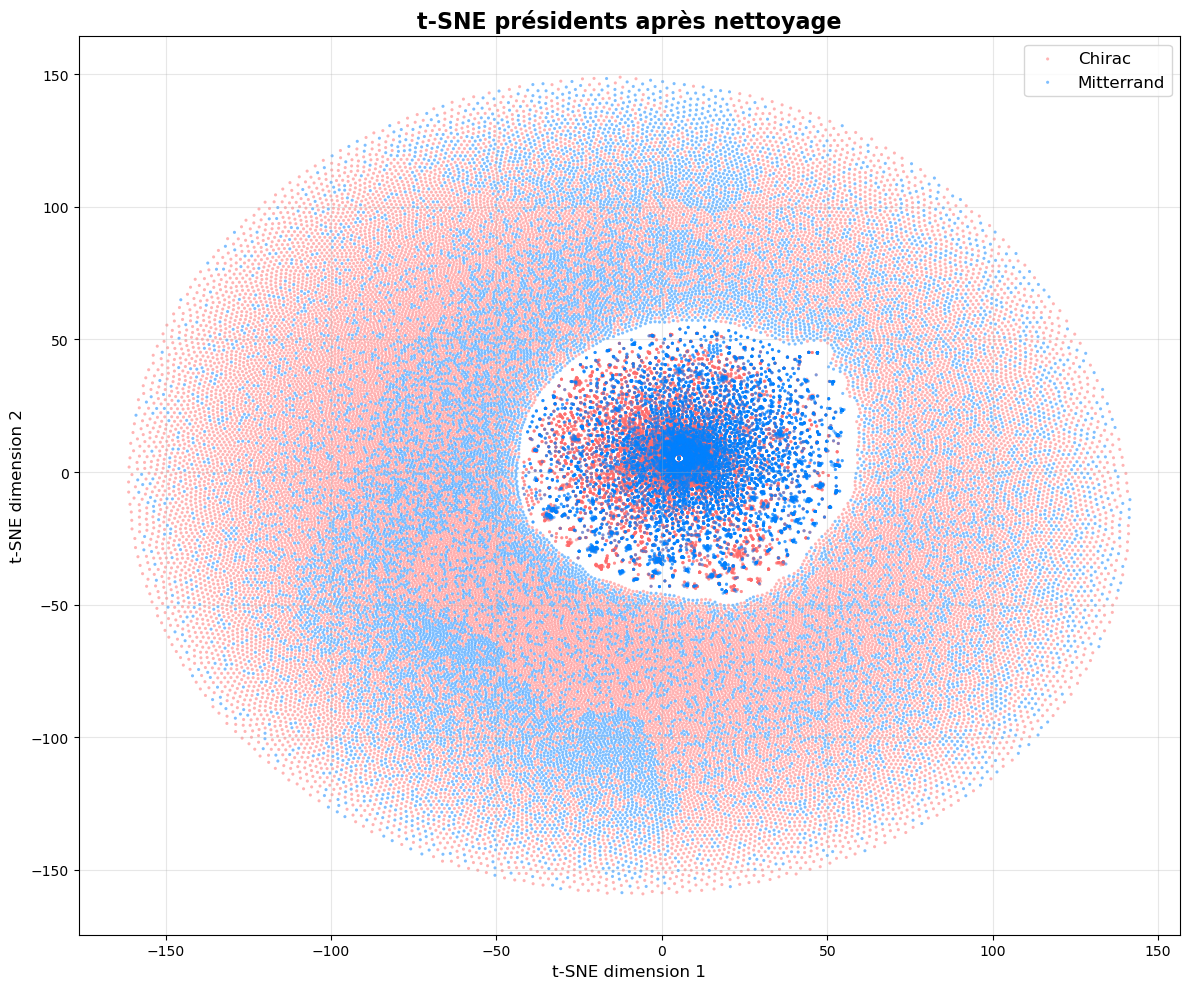

In [336]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(cleaned_texts)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tfidf_tsne = tsne.fit_transform(tfidf_matrix.toarray())


fig, ax = plt.subplots(figsize=(12, 10))

for label, color, name in zip([0, 1], colors, class_names):
    mask = np.array(labels) == label
    ax.scatter(tfidf_tsne[mask, 0], tfidf_tsne[mask, 1], 
               c=color, label=name, alpha=0.5, s=5, edgecolors='none')

ax.set_title('t-SNE présidents après nettoyage', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1', fontsize=12)
ax.set_ylabel('t-SNE dimension 2', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_cleaned_pres.png', dpi=300, bbox_inches='tight')
plt.show()

## Entrainement 

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    final_texts, final_labels, test_size=0.2, random_state=42, stratify=final_labels, shuffle=True
)

In [ ]:
C = 1

models = {
    #"logreg": LogisticRegression(max_iter=3000),
    #"svm": LinearSVC(C=C, class_weight="balanced")
    "svm_calibrated": CalibratedClassifierCV(estimator=LinearSVC(class_weight="balanced",C=C),method="sigmoid")
}

best_model_name = None
best_score = 0
best_pipeline = None
custom_stopwords = [
    "monsieur", "madame", "messieurs", "mesdames",
    "président", "france", "vive", "monsieur le président",
    "république", "gouvernement"
]

for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words=custom_stopwords, 
                                  preprocessor = preprocess_pres,
                                  # analyzer="char",
                                  # ngram_range=(3,5), 
                                  ngram_range=(1,3),
                                  min_df=2,
                                  max_df=0.8,
                                  max_features = 10000,
                                  sublinear_tf=True,
                                  lowercase= True
                                    )
                                  ),
        #("tfidf", TfidfVectorizer(ngram_range=(3,5), min_df = 2, max_features=30000, max_df=0.8, analyzer="char", sublinear_tf=True)),
        ("clf",clf)
    ])

    print("debut entrainement")
    pipe.fit(X_train,y_train)
    print("fin entrainement")
    train_preds = pipe.predict(X_train)
    print("predictions train faites")
    val_preds = pipe.predict(X_val)
    print("predictions val faites")

    train_f1 = f1_score(y_train, train_preds, average="macro")
    val_f1 = f1_score(y_val, val_preds, average="macro")

    print(f"\n{name}")
    print(f"Train F1: {train_f1:.4f}")
    print(f"Val F1:   {val_f1:.4f}")
    print(classification_report(y_val, val_preds, digits=4))

    if val_f1 > best_score:
        best_score = val_f1
        best_model_name = name
        best_pipeline = pipe

print(f"\nBest model: {best_model_name} (F1: {best_score:.4f})")

debut entrainement
fin entrainement
predictions train faites
predictions val faites

svm_calibrated
Train F1: 0.8892
Val F1:   0.8307
              precision    recall  f1-score   support

           0     0.8524    0.8903    0.8710      8980
           1     0.8193    0.7634    0.7904      5850

    accuracy                         0.8403     14830
   macro avg     0.8359    0.8269    0.8307     14830
weighted avg     0.8394    0.8403    0.8392     14830


Best model: svm_calibrated (F1: 0.8307)


In [ ]:
texts = np.concatenate([X_train , X_val])
labels =  np.concatenate([y_train , y_val]) 



In [ ]:
best_pipeline.fit(texts,labels)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.8, max_features=10000, min_df=2,
                                 ngram_range=(1, 3),
                                 preprocessor=<function preprocess_pres at 0x000002D0CDBA23E0>,
                                 stop_words=['monsieur', 'madame', 'messieurs',
                                             'mesdames', 'président', 'france',
                                             'vive', 'monsieur le président',
                                             'république', 'gouvernement'],
                                 sublinear_tf=True)),
                ('clf',
                 CalibratedClassifierCV(estimator=LinearSVC(C=1,
                                                            class_weight='balanced')))])

In [207]:
best_pipeline = joblib.load("tf_idf_svm_pres.pkl")


=== FINAL TEST RESULTS ===
Accuracy: 0.8549285963079066
F1 macro: 0.7345218857321261

=== PER CLASS METRICS ===
              precision    recall  f1-score   support

           0     0.9500    0.8794    0.9133      4990
           1     0.4639    0.6928    0.5557       752

    accuracy                         0.8549      5742
   macro avg     0.7070    0.7861    0.7345      5742
weighted avg     0.8863    0.8549    0.8665      5742



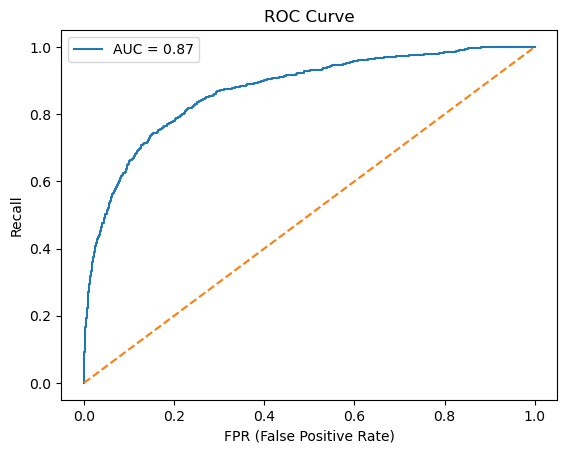

In [ ]:
test_preds = best_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, test_preds))
print("F1 macro:", f1_score(y_test, test_preds, average="macro"))

print(classification_report(y_test, test_preds, digits=4))


if hasattr(best_pipeline, "decision_function"):
    scores = best_pipeline.decision_function(X_test)
else:
    scores = best_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("Recall")
plt.legend()
plt.title("ROC Curve")
plt.show()

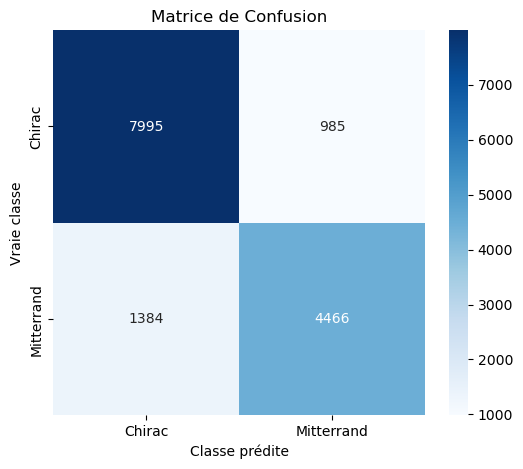

              precision    recall  f1-score   support

      Chirac       0.85      0.89      0.87      8980
  Mitterrand       0.82      0.76      0.79      5850

    accuracy                           0.84     14830
   macro avg       0.84      0.83      0.83     14830
weighted avg       0.84      0.84      0.84     14830



In [ ]:
import seaborn as sns

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Chirac', 'Mitterrand'], 
            yticklabels=['Chirac', 'Mitterrand'])
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion')
plt.show()


In [317]:
preds = best_pipeline.predict_proba(test_texts)

proba_class_1 = preds[:, 1]

np.savetxt("testing.csv", proba_class_1, fmt="%.8f")


### Grid Search

In [ ]:


pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC(class_weight="balanced"))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.8, 0.9, 1.0],
    "tfidf__sublinear_tf": [True],
    
    "clf__C": [0.3, 0.5, 0.7, 1.0, 2.0]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

train_preds = best_model.predict(X_train)
val_preds = best_model.predict(X_val)

print("\nTrain F1:", f1_score(y_train, train_preds, average="macro"))
print("Val F1:", f1_score(y_val, val_preds, average="macro"))

print("\n", classification_report(y_val, val_preds, digits=4))

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best params: {'clf__C': 2.0, 'tfidf__max_df': 0.6, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True}
Best CV score: 0.825995485577358

Train F1: 0.9980382724824131
Val F1: 0.8482359962140749

               precision    recall  f1-score   support

           0     0.8783    0.8836    0.8810      8980
           1     0.8193    0.8117    0.8155      5837

    accuracy                         0.8553     14817
   macro avg     0.8488    0.8477    0.8482     14817
weighted avg     0.8551    0.8553    0.8552     14817



## Experiences générales

In [4]:
#Test Preprocess
clean_fonc={"clean_1": clean_1,"clean_2": clean_2,"clean_3": clean_3,"clean_4": clean_4}
results = list()


In [5]:
if RUN_CLASSICAL:
    classical_families = {
        "tfidf_logreg_word": tfidf_logreg,
        "tfidf_logreg_char": tfidf_logreg_char,
        "tfidf_svm_char": tfidf_svm,
    }

    for prepname, prepfn in clean_fonc.items():
        X_train_prep = [prepfn(t) for t in X_train]
        X_valid_prep = [prepfn(t) for t in X_valid]

        for modelname, builder in classical_families.items():
            exp_name = f"{modelname}__{prepname}"
            model, saved_path = train_or_load_sklearn(
                MODELS_ROOT, exp_name, builder, X_train_prep, y_train
            )

            metrics = evaluate_model(model, X_valid_prep, y_valid)
            print_metrics(exp_name, metrics)

            results.append({
                "model": modelname,
                "preprocessing f": prepname,
                "exp_name": exp_name,
                "save_path": saved_path,
                **metrics
            })

[LOAD] ../../Models/Dialogs\tfidf_logreg_word__clean_1.joblib
tfidf_logreg_word__clean_1
Accuracy  : 0.8722
F1-score  : 0.5834
Precision : 0.5094
Recall    : 0.6824
Log-loss  : 0.3272
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               8989                989
Vrai Mitterrand            478               1027
[LOAD] ../../Models/Dialogs\tfidf_logreg_char__clean_1.joblib
tfidf_logreg_char__clean_1
Accuracy  : 0.8450
F1-score  : 0.5514
Precision : 0.4442
Recall    : 0.7269
Log-loss  : 0.3690
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               8609               1369
Vrai Mitterrand            411               1094
[LOAD] ../../Models/Dialogs\tfidf_svm_char__clean_1.joblib
tfidf_svm_char__clean_1
Accuracy  : 0.9033
F1-score  : 0.5018
Precision : 0.7732
Recall    : 0.3714
Log-loss  : 0.2557
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               9814                1

In [6]:
if RUN_W2V:
    for prepname, prepfn in clean_fonc.items():
        X_train_prep = [prepfn(t) for t in X_train]
        X_valid_prep = [prepfn(t) for t in X_valid]

        exp_name = f"w2v_logreg__{prepname}"

        model, saved_path = train_or_load_w2v(
            MODELS_ROOT, exp_name, w2v_logreg, X_train_prep, y_train,X_valid,y_valid
        )

        metrics = evaluate_model(model, X_valid_prep, y_valid)
        print_metrics(exp_name, metrics)

        results.append({
            "model": "w2v_logreg",
            "preprocessing f": prepname,
            "exp_name": exp_name,
            "save_path": saved_path,
            **metrics
        })

[LOAD] ../../Models/Dialogs\w2v_logreg__clean_1.joblib
w2v_logreg__clean_1
Accuracy  : 0.7379
F1-score  : 0.4198
Precision : 0.2957
Recall    : 0.7236
Log-loss  : 0.5490
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               7384               2594
Vrai Mitterrand            416               1089
[LOAD] ../../Models/Dialogs\w2v_logreg__clean_2.joblib
w2v_logreg__clean_2
Accuracy  : 0.7377
F1-score  : 0.4140
Precision : 0.2927
Recall    : 0.7070
Log-loss  : 0.5554
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               7407               2571
Vrai Mitterrand            441               1064
[LOAD] ../../Models/Dialogs\w2v_logreg__clean_3.joblib
w2v_logreg__clean_3
Accuracy  : 0.7427
F1-score  : 0.4236
Precision : 0.2998
Recall    : 0.7216
Log-loss  : 0.5479
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               7442               2536
Vrai Mitterrand            419   

In [7]:
if RUN_RNN:
    for prepname, prepfn in clean_fonc.items():
        X_train_prep = [prepfn(t) for t in X_train]
        X_valid_prep = [prepfn(t) for t in X_valid]

        exp_name = f"rnn_lstm__{prepname}"

        model, saved_path = train_or_load_rnn(
            MODELS_ROOT,
            exp_name,
            rnn_lstm,
            X_train_prep,
            y_train,
            X_valid_prep,
            y_valid
        )

        metrics = evaluate_model(model, X_valid_prep, y_valid)
        print_metrics(exp_name, metrics)

        results.append({
            "model": "rnn_lstm",
            "preprocessing f": prepname,
            "exp_name": exp_name,
            "save_path": saved_path,
            **metrics
        })

[LOAD] ../../Models/Dialogs\rnn_lstm__clean_1.pt
rnn_lstm__clean_1
Accuracy  : 0.8514
F1-score  : 0.5251
Precision : 0.4518
Recall    : 0.6266
Log-loss  : 0.7846
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               8834               1144
Vrai Mitterrand            562                943
[LOAD] ../../Models/Dialogs\rnn_lstm__clean_2.pt
rnn_lstm__clean_2
Accuracy  : 0.8364
F1-score  : 0.4782
Precision : 0.4108
Recall    : 0.5721
Log-loss  : 0.9615
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               8743               1235
Vrai Mitterrand            644                861
[LOAD] ../../Models/Dialogs\rnn_lstm__clean_3.pt
rnn_lstm__clean_3
Accuracy  : 0.8598
F1-score  : 0.5228
Precision : 0.4719
Recall    : 0.5860
Log-loss  : 0.8174
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               8991                987
Vrai Mitterrand            623                882
[LOAD] 

In [8]:
if RUN_TRANSFORMER:
    transformer_preps = {
        "clean_4": clean_4,
        "clean_1": clean_1
    }
    for prepname, prepfn in transformer_preps.items():
        X_train_prep = [prepfn(t) for t in X_train]
        X_valid_prep = [prepfn(t) for t in X_valid]
        exp_name = f"camembert_trainer__{prepname}"

        model, saved_path = train_or_load_transformer(
            MODELS_ROOT,
            exp_name,
            build_transformer,
            X_train_prep,
            y_train,
            X_valid_prep,
            y_valid
        )

        metrics = evaluate_model(model, X_valid_prep, y_valid)
        print_metrics(exp_name, metrics)

        results.append({
            "model": "camembert_trainer",
            "preprocessing f": prepname,
            "exp_name": exp_name,
            "save_path": saved_path,
            **metrics
        })

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 370.57it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


[LOAD] ../../Models/Dialogs\camembert_trainer__clean_4


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 379.58it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

camembert_trainer__clean_4
Accuracy  : 0.9201
F1-score  : 0.6316
Precision : 0.7974
Recall    : 0.5229
Log-loss  : 0.3447
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               9778                200
Vrai Mitterrand            718                787


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 362.68it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


[LOAD] ../../Models/Dialogs\camembert_trainer__clean_1


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 415.29it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

camembert_trainer__clean_1
Accuracy  : 0.9167
F1-score  : 0.5997
Precision : 0.8109
Recall    : 0.4757
Log-loss  : 0.4161
Confusion matrix :
                 Prédit Chirac  Prédit Mitterrand
Vrai Chirac               9811                167
Vrai Mitterrand            789                716


In [9]:
#results["model"] = results["model"].str.split("__clean").str[0]
results

[{'model': 'tfidf_logreg_word',
  'preprocessing f': 'clean_1',
  'exp_name': 'tfidf_logreg_word__clean_1',
  'save_path': '../../Models/Dialogs\\tfidf_logreg_word__clean_1.joblib',
  'accuracy': 0.8722459287642602,
  'f1': 0.5833570008520307,
  'precision': 0.5094246031746031,
  'recall': 0.6823920265780731,
  'log_loss': 0.32723603128100415,
  'confusion_matrix': array([[8989,  989],
         [ 478, 1027]])},
 {'model': 'tfidf_logreg_char',
  'preprocessing f': 'clean_1',
  'exp_name': 'tfidf_logreg_char__clean_1',
  'save_path': '../../Models/Dialogs\\tfidf_logreg_char__clean_1.joblib',
  'accuracy': 0.844988243490377,
  'f1': 0.5514112903225806,
  'precision': 0.4441737718229801,
  'recall': 0.7269102990033223,
  'log_loss': 0.36896288958297946,
  'confusion_matrix': array([[8609, 1369],
         [ 411, 1094]])},
 {'model': 'tfidf_svm_char',
  'preprocessing f': 'clean_1',
  'exp_name': 'tfidf_svm_char__clean_1',
  'save_path': '../../Models/Dialogs\\tfidf_svm_char__clean_1.joblib'

In [10]:
results = pd.DataFrame([{
    "model": r["model"],
    "preprocessing f": r["preprocessing f"],
    "exp_name": r["exp_name"],
    "save_path": r["save_path"],
    "accuracy": r["accuracy"],
    "f1": r["f1"],
    "precision": r["precision"],
    "recall": r["recall"],
    "log_loss": r["log_loss"],
} for r in results])

results = results.sort_values(by=["f1", "log_loss"], ascending=[False, True]).reset_index(drop=True)
results

,model,preprocessing f,exp_name,save_path,accuracy,f1,precision,recall,log_loss
0,camembert_trainer,clean_4,camembert_trainer__clean_4,../../Models/Dialogs\camembert_trainer__clean_4,0.920056,0.631621,0.797366,0.522924,0.344683
1,tfidf_logreg_word,clean_4,tfidf_logreg_word__clean_4,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.882957,0.609983,0.541473,0.698339,0.316568
2,camembert_trainer,clean_1,camembert_trainer__clean_1,../../Models/Dialogs\camembert_trainer__clean_1,0.916746,0.599665,0.810872,0.475748,0.416060
3,tfidf_logreg_word,clean_1,tfidf_logreg_word__clean_1,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.872246,0.583357,0.509425,0.682392,0.327236
4,tfidf_logreg_word,clean_3,tfidf_logreg_word__clean_3,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.872246,0.583357,0.509425,0.682392,0.327236
5,tfidf_logreg_char,clean_4,tfidf_logreg_char__clean_4,../../Models/Dialogs\tfidf_logreg_char__clean_...,0.858835,0.575766,0.474957,0.730897,0.346358
6,tfidf_logreg_word,clean_2,tfidf_logreg_word__clean_2,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.862579,0.554489,0.482081,0.652492,0.347788
7,tfidf_logreg_char,clean_1,tfidf_logreg_char__clean_1,../../Models/Dialogs\tfidf_logreg_char__clean_...,0.844988,0.551411,0.444174,0.726910,0.368963
8,tfidf_logreg_char,clean_3,tfidf_logreg_char__clean_3,../../Models/Dialogs\tfidf_logreg_char__clean_...,0.842550,0.546867,0.439034,0.724917,0.374856
9,tfidf_svm_char,clean_4,tfidf_svm_char__clean_4,../../Models/Dialogs\tfidf_svm_char__clean_4.j...,0.905512,0.530100,0.761194,0.406645,0.242698


In [11]:
best_by_model = []

for m, group in results.groupby("model"):
    best_row = group.sort_values(by=["f1", "log_loss"], ascending=[False, True]).iloc[0]
    best_by_model.append(best_row)

    src = best_row["save_path"]

    if m == "camembert_trainer":
        dst = os.path.join(MODELS_ROOT, "BEST", f"{m}__BEST")
    elif m == "rnn_lstm":
        dst = os.path.join(MODELS_ROOT, "BEST", f"{m}__BEST.pt")
    else:
        dst = os.path.join(MODELS_ROOT, "BEST", f"{m}__BEST.joblib")

    os.makedirs(os.path.dirname(dst), exist_ok=True)
    copy_any(src, dst)

best_by_model = pd.DataFrame(best_by_model).sort_values(
    by=["f1", "log_loss"], ascending=[False, True]
).reset_index(drop=True)

best_by_model

,model,preprocessing f,exp_name,save_path,accuracy,f1,precision,recall,log_loss
0,camembert_trainer,clean_4,camembert_trainer__clean_4,../../Models/Dialogs\camembert_trainer__clean_4,0.920056,0.631621,0.797366,0.522924,0.344683
1,tfidf_logreg_word,clean_4,tfidf_logreg_word__clean_4,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.882957,0.609983,0.541473,0.698339,0.316568
2,tfidf_logreg_char,clean_4,tfidf_logreg_char__clean_4,../../Models/Dialogs\tfidf_logreg_char__clean_...,0.858835,0.575766,0.474957,0.730897,0.346358
3,tfidf_svm_char,clean_4,tfidf_svm_char__clean_4,../../Models/Dialogs\tfidf_svm_char__clean_4.j...,0.905512,0.530100,0.761194,0.406645,0.242698
4,rnn_lstm,clean_1,rnn_lstm__clean_1,../../Models/Dialogs\rnn_lstm__clean_1.pt,0.851433,0.525056,0.451845,0.626578,0.784629
5,w2v_logreg,clean_4,w2v_logreg__clean_4,../../Models/Dialogs\w2v_logreg__clean_4.joblib,0.749804,0.431202,0.307107,0.723588,0.544611


In [12]:
the_best = results.iloc[0]
the_best

model                                            camembert_trainer
preprocessing f                                            clean_4
exp_name                                camembert_trainer__clean_4
save_path          ../../Models/Dialogs\camembert_trainer__clean_4
accuracy                                                  0.920056
f1                                                        0.631621
precision                                                 0.797366
recall                                                    0.522924
log_loss                                                  0.344683
Name: 0, dtype: object

In [13]:
src = the_best["save_path"]

if the_best["model"] == "camembert_trainer":
    dst = os.path.join(MODELS_ROOT, "THE BEST", "MODEL")
else:
    ext = ".pt" if the_best["model"] == "rnn_lstm" else ".joblib"
    dst = os.path.join(MODELS_ROOT, "THE BEST", f"MODEL{ext}")

os.makedirs(os.path.dirname(dst), exist_ok=True)
copy_any(src, dst)
save_json(the_best.to_dict(), os.path.join(MODELS_ROOT, "THE BEST", "metadata.json"))

In [14]:
best_model = the_best["model"]
best_prepname = the_best["preprocessing f"]
best_prepfn = clean_fonc[best_prepname]
best_exp_name = the_best["exp_name"]

final_train = [best_prepfn(t) for t in train_texts]
final_test = [best_prepfn(t) for t in test_texts]


In [15]:
if best_model in {"tfidf_logreg_word", "tfidf_logreg_char", "tfidf_svm_char"}:
    final_model, _ = load_sklearn_model(MODELS_ROOT, best_exp_name)
    if final_model is None:
        builders = {
            "tfidf_logreg_word": tfidf_logreg,
            "tfidf_logreg_char": tfidf_logreg_char,
            "tfidf_svm_char": tfidf_svm,
        }
        final_model = builders[best_model]()
        final_model.fit(final_train, labels)
        save_sklearn_model(final_model, MODELS_ROOT, best_exp_name)

elif "w2v_logreg" == best_model:
    final_model, _ = load_sklearn_model(MODELS_ROOT, best_exp_name)
    if final_model is None:
        final_model = w2v_logreg()
        final_model.fit(final_train, labels)
        save_sklearn_model(final_model, MODELS_ROOT, best_exp_name)

elif "rnn_lstm" == best_model:
    final_model, _ = train_or_load_rnn(
        MODELS_ROOT,
        best_exp_name,
        rnn_lstm,
        final_train,
        labels
    )

elif "camembert_trainer" == best_model:
    final_model, _ = train_or_load_transformer(
        MODELS_ROOT,
        best_exp_name,
        build_transformer,
        final_train,
        labels
    )

else:
    raise ValueError(f"Modèle non géré: {best_model}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 366.85it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


[LOAD] ../../Models/Dialogs\camembert_trainer__clean_4


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 400.44it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [16]:
proba_test = final_model.predict_proba(final_test)[:, 1]
submission_df = pd.DataFrame(proba_test)

Map: 100%|██████████| 27162/27162 [00:01<00:00, 19197.72 examples/s]


../../Results/Dialogs\submission_01.csv


,0
0,0.004855
1,0.004932
2,0.020104
3,0.997351
4,0.064228
5,0.997310
6,0.006531
7,0.004894
8,0.005102
9,0.004936


In [37]:
submission_path = os.path.join(RESULT_ROOT, "submission-pres-1.csv")
submission_df.to_csv(submission_path, index=False, header=False)

print(submission_path)
submission_df.head(10)

../../Results/Dialogs\submission-pres-1.csv


,0
0,0.004855
1,0.004932
2,0.020104
3,0.997351
4,0.064228
5,0.997310
6,0.006531
7,0.004894
8,0.005102
9,0.004936


In [17]:
submission_df[submission_df[0]>0.5]

,0
3,0.997351
5,0.997310
37,0.517151
41,0.942734
43,0.997341
...,...
26106,0.997350
26133,0.917369
26249,0.994421
26673,0.995267


In [18]:
submission_df[submission_df[0]<0.5]

,0
0,0.004855
1,0.004932
2,0.020104
4,0.064228
6,0.006531
...,...
27157,0.004881
27158,0.004911
27159,0.004979
27160,0.004872


Composé

In [19]:
part_f = best_by_model[best_by_model["model"].isin(
    ["tfidf_logreg_word", "tfidf_logreg_char", "camembert_trainer"]
)]


In [20]:
part_f

,model,preprocessing f,exp_name,save_path,accuracy,f1,precision,recall,log_loss
0,camembert_trainer,clean_4,camembert_trainer__clean_4,../../Models/Dialogs\camembert_trainer__clean_4,0.920056,0.631621,0.797366,0.522924,0.344683
1,tfidf_logreg_word,clean_4,tfidf_logreg_word__clean_4,../../Models/Dialogs\tfidf_logreg_word__clean_...,0.882957,0.609983,0.541473,0.698339,0.316568
2,tfidf_logreg_char,clean_4,tfidf_logreg_char__clean_4,../../Models/Dialogs\tfidf_logreg_char__clean_...,0.858835,0.575766,0.474957,0.730897,0.346358


In [21]:
final_train = [clean_4(t) for t in train_texts]
final_test = [clean_4(t) for t in test_texts]

In [22]:
final_tfidf_logreg_word=train_or_load_sklearn(f"{MODELS_ROOT}/THE BEST/MODEL COMP","tfidf_logreg_word__final",tfidf_logreg,final_train,labels)[0]
final_tfidf_logreg_char=train_or_load_sklearn(f"{MODELS_ROOT}/THE BEST/MODEL COMP","tfidf_logreg_char__final",tfidf_logreg_char,final_train,labels)[0]


[LOAD] ../../Models/Dialogs/THE BEST/MODEL COMP\tfidf_logreg_word__final.joblib
[LOAD] ../../Models/Dialogs/THE BEST/MODEL COMP\tfidf_logreg_char__final.joblib


In [23]:
proba_word = final_tfidf_logreg_word.predict_proba(final_test)[:, 1]
proba_char = final_tfidf_logreg_char.predict_proba(final_test)[:, 1]
proba_trf  = final_model.predict_proba(final_test)[:, 1] # Le meilleur modèle

Map: 100%|██████████| 27162/27162 [00:01<00:00, 18865.01 examples/s]


In [24]:
proba_char

array([0.09341093, 0.19210546, 0.22862354, ..., 0.16871242, 0.02273102,
       0.6757705 ], shape=(27162,))

In [25]:
proba_word

array([0.05116936, 0.35112714, 0.28161799, ..., 0.137766  , 0.02619816,
       0.57499655], shape=(27162,))

In [26]:
proba_trf

array([0.00485545, 0.00493241, 0.0201038 , ..., 0.00497888, 0.00487165,
       0.00738183], shape=(27162,), dtype=float32)

In [41]:
proba = (
    0.5 * proba_word +
    0.3 * proba_trf +
    0.2 * proba_char
)

In [42]:
# recentrage (améliore recall)
proba = (proba - 0.5) * 1.15 + 0.5

# clipping (stabilité)
proba = np.clip(proba, 0.02, 0.98)

predy_1=np.where(proba>0.5,1,np.where(proba < 0.5, 0, 0))

In [43]:
submission = pd.DataFrame(proba)
submission_path = os.path.join(RESULT_ROOT, "submission-pres-2.csv")
submission_df.to_csv(submission_path, index=False, header=False)

In [44]:
proba = (
    0.55 * proba_word +
    0.35 * proba_trf +
    0.10 * proba_char
)

In [45]:
predy_2=np.where(proba>0.5,1,np.where(proba < 0.5, 0, 0))

In [46]:
# recentrage (améliore recall)
proba = (proba - 0.5) * 1.15 + 0.5

# clipping (stabilité)
proba = np.clip(proba, 0.02, 0.98)

In [47]:
submission = pd.DataFrame(proba)
submission_path = os.path.join(RESULT_ROOT, "submission-pres-3.csv")
submission_df.to_csv(submission_path, index=False, header=False)

In [48]:
len(np.where(predy_1 != predy_2)[0])

287